# Gated Recurrent Unit Recurrent Neural Networks (GRU RNNs)

## What is a Recurrent Neural Network (RNN)?
A Recurrent Neural Network (RNN) belongs to the class of artificial
neural networks where **connections between units form a directed cycle**.

This allows RNNs to:
- Retain important data from previous inputs
- Use that past information to modify the current output
- Essentially giving the network **memory**

This makes RNNs naturally suited for **time series data** like stock returns,
where past values influence future values.

## Problem with Vanilla RNNs — Vanishing Gradient
During training, gradients (error signals) are propagated backwards
through time. For long sequences, these gradients become extremely small
(**vanish**) making it impossible to learn long-term dependencies.

## Solution — Long Short-Term Memory (LSTM)
LSTM RNNs solve the vanishing gradient problem by introducing:
- **Input gate** → controls what new information enters memory
- **Forget gate** → controls what old information is discarded
- **Output gate** → controls what information is output
- **Cell state** → carries long-term memory across time steps

## GRU — Simplified LSTM
Cho et al. (2014) proposed the **Gated Recurrent Unit (GRU)** as a
simpler variation of LSTM:

Key simplifications:
1. Combines forget and input gates into single **Update Gate (z_t)**
2. Merges cell state and hidden state into one
3. Adds **Reset Gate (r_t)**

This makes GRU:
- Simpler architecture than LSTM
- Fewer parameters to train
- Faster to train
- Comparable performance to LSTM

## GRU Equations

    z_t = σ(W_z · [h_{t-1}, x_t])          (Update Gate)    ...(2)
    r_t = σ(W_r · [h_{t-1}, x_t])          (Reset Gate)     ...(3)
    h̃_t = tanh(W · [r_t * h_{t-1}, x_t])  (Candidate)      ...(4)
    h_t = (1 - z_t) * h_{t-1} + z_t * h̃_t (Output)         ...(5)

Where:
- x_t       → input vector (5 FF factors at time t)
- h_{t-1}   → previous hidden state
- z_t       → update gate (how much past to keep)
- r_t       → reset gate (how much past to forget)
- h̃_t      → candidate activation vector
- h_t       → final output hidden state
- σ         → sigmoid function (output between 0 and 1)
- tanh      → rescaled sigmoid (output between -1 and 1)
- W         → weight matrices (learned during training)

## Update Gate Intuition
- z_t close to 1 → keep more of previous hidden state (long memory)
- z_t close to 0 → replace with new candidate (short memory)
- This allows GRU to decide how far back to remember

## Reset Gate Intuition
- r_t close to 1 → use full previous hidden state
- r_t close to 0 → ignore previous hidden state (fresh start)

## Our GRU Architecture (from paper)
| Layer | Details |
|-------|---------|
| Input | 5 FF factors, time_step = 1 |
| GRU Layer 1 | 400 neurons, dropout = 0.2 |
| GRU Layer 2 | 400 neurons, dropout = 0.2 |
| Output (Dense) | 1 neuron (next day excess return) |

## Why Dropout?
Dropout randomly drops units and their connections during training:
- Prevents units from co-adapting too much
- Avoids overfitting the training data
- Dropout = 0.2 means 20% of neurons are randomly dropped each step

## Why GRU beats FFFFM and SVR here?
- Captures **nonlinear** relationships (unlike FFFFM)
- Has **memory** — uses temporal patterns in factor data
- Two hidden layers allow **deeper feature extraction**
- Empirically shown to give best R² among the three models

In [2]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── TENSORFLOW / KERAS ─────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# ── ENVIRONMENT SETUP ──────────────────────────────────────
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/portfolio_project'
else:
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..','data','portfolio_project'))

print(f"\nUsing: {BASE_DIR}")

# ── LOAD DATA ──────────────────────────────────────────────
train = pd.read_csv(os.path.join(BASE_DIR, 'train_data.csv'),
                    index_col='Date', parse_dates=True)
valid = pd.read_csv(os.path.join(BASE_DIR, 'valid_data.csv'),
                    index_col='Date', parse_dates=True)

print(f"Train: {train.shape}")
print(f"Valid: {valid.shape}")

# ── FEATURES & TARGETS ─────────────────────────────────────
feature_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

X_train_raw = train[feature_cols].values
X_valid_raw = valid[feature_cols].values

targets = {
    'MSFT': (train['MSFT_excess'].values, valid['MSFT_excess'].values),
    'AAPL': (train['AAPL_excess'].values, valid['AAPL_excess'].values),
    'SONY': (train['SONY_excess'].values, valid['SONY_excess'].values),
}

TensorFlow version: 2.21.0
GPU available: []

Using: /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/portfolio_project
Train: (2999, 12)
Valid: (499, 12)


In [3]:
# ── SCALE FEATURES ─────────────────────────────────────────
# GRU is sensitive to feature scale
# Fit ONLY on train, apply same to valid
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print("Scaling done!")
print(f"X_train mean: {X_train.mean(axis=0).round(4)}")  # ~0
print(f"X_train std : {X_train.std(axis=0).round(4)}")   # ~1

Scaling done!
X_train mean: [-0. -0.  0. -0.  0.]
X_train std : [1. 1. 1. 1. 1.]


## Why Reshape for GRU?

Standard data shape:    (samples, features)      e.g. (2996, 5)
GRU expects:           (samples, timesteps, features)  e.g. (2996, 1, 5)

Since the paper uses **time_step = 1** (predicting next day return
using current day factors), we simply add an extra dimension.

This tells the GRU:
- 2996 samples
- 1 time step per sample
- 5 features per time step

In [4]:
# ── RESHAPE FOR GRU ────────────────────────────────────────
# (samples, features) → (samples, timesteps=1, features)
X_train_gru = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_valid_gru = X_valid.reshape(X_valid.shape[0], 1, X_valid.shape[1])

print(f"X_train shape for GRU: {X_train_gru.shape}")  # (2996, 1, 5)
print(f"X_valid shape for GRU: {X_valid_gru.shape}")  # (504, 1, 5)

X_train shape for GRU: (2999, 1, 5)
X_valid shape for GRU: (499, 1, 5)


## GRU Model Architecture

Input (5 factors, timestep=1)

↓

GRU Layer 1 (400 neurons, return_sequences=True)

↓

Dropout (0.2)

↓

GRU Layer 2 (400 neurons, return_sequences=False)

↓

Dropout (0.2)

↓

Dense Output Layer (1 neuron)

↓

Predicted excess return for next day

- **return_sequences=True** in Layer 1 → passes full sequence to Layer 2
- **return_sequences=False** in Layer 2 → only last output passed to Dense
- **Loss function**: Mean Squared Error (MSE) — standard for regression
- **Optimizer**: Adam — adaptive learning rate, works well for RNNs
- **Early Stopping**: stops training if validation loss stops improving
  → prevents overfitting, saves training time

In [5]:
def build_gru_model(input_shape):
    """
    Build GRU RNN as described in paper:
    - 2 GRU hidden layers with 400 neurons each
    - Dropout = 0.2 after each GRU layer
    - Dense output layer with 1 neuron
    """
    model = Sequential([
        GRU(400,
            return_sequences=True,
            input_shape=input_shape),
        Dropout(0.2),

        GRU(400,
            return_sequences=False),
        Dropout(0.2),

        Dense(1)   # output: next day excess return
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

# Preview architecture
sample_model = build_gru_model((1, 5))
sample_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 400)         │       488,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 400)            │       962,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,451,201 (5.54 MB)

 Trainable params: 1,451,201 (5.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

EPOCHS     = 500      # increased significantly
BATCH_SIZE = 32

gru_models  = {}
gru_r2      = {}
gru_preds   = {}
gru_history = {}

print("=" * 50)
print("GRU RNNs — Training")
print("=" * 50)

for stock, (y_train, y_valid) in targets.items():
    print(f"\nTraining GRU for {stock}...")

    tf.keras.backend.clear_session()  # fresh session each stock

    model = build_gru_model((1, 5))

    # ← fresh callbacks inside loop, not outside
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True,
        min_delta=0.00001
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-7,
        verbose=0
    )

    history = model.fit(
        X_train_gru, y_train,
        validation_data=(X_valid_gru, y_valid),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    y_pred = model.predict(X_valid_gru).flatten()
    r2     = r2_score(y_valid, y_pred)

    gru_models[stock]  = model
    gru_r2[stock]      = r2
    gru_preds[stock]   = y_pred
    gru_history[stock] = history

    print(f"  {stock} → R²: {r2:.4f}")
    print(f"  Stopped at epoch: {len(history.history['loss'])}")

print("\n" + "=" * 50)
print("Summary R² values:")
for stock, r2 in gru_r2.items():
    print(f"  {stock}: {r2:.3f}")

GRU RNNs — Training

Training GRU for MSFT...
Epoch 1/500


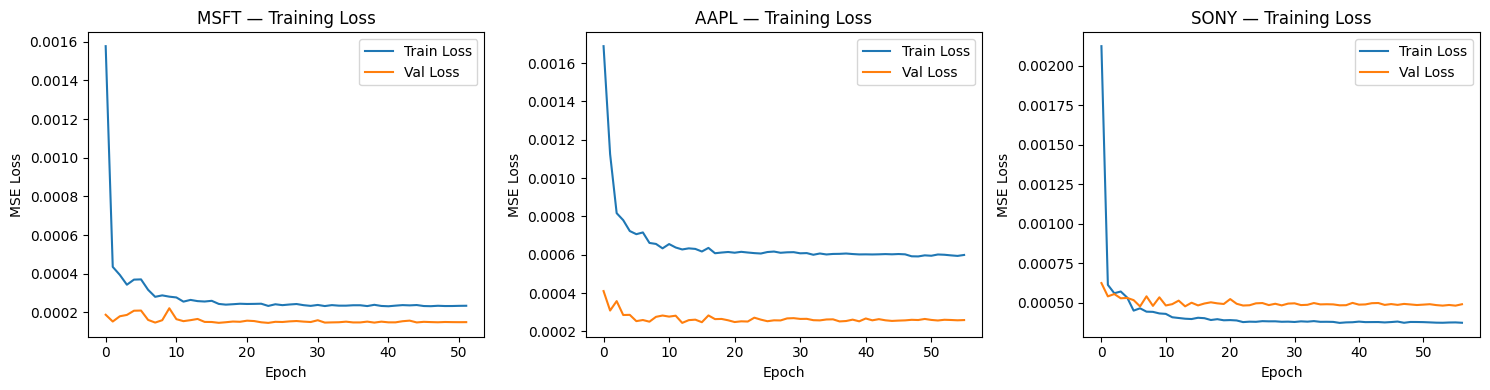

Saved: /content/drive/MyDrive/portfolio_project/gru_training_loss.png


In [ ]:
# ── PLOT TRAINING LOSS ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, stock in enumerate(['MSFT', 'AAPL', 'SONY']):
    history = gru_history[stock]
    axes[idx].plot(history.history['loss'],     label='Train Loss')
    axes[idx].plot(history.history['val_loss'], label='Val Loss')
    axes[idx].set_title(f'{stock} — Training Loss')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('MSE Loss')
    axes[idx].legend()

plt.tight_layout()
loss_path = os.path.join(BASE_DIR, 'gru_training_loss.png')
plt.savefig(loss_path, dpi=150)
plt.show()
print(f"Saved: {loss_path}")

In [ ]:
print("=" * 50)
print("GRU — 20-Fold Cross Validation & P-values")
print("=" * 50)

X_all_gru = np.vstack([X_train, X_valid])
X_all_gru = X_all_gru.reshape(X_all_gru.shape[0], 1, X_all_gru.shape[1])

kf = KFold(n_splits=20, shuffle=False)

for stock, (y_train, y_valid) in targets.items():
    y_all     = np.concatenate([y_train, y_valid])
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_all_gru)):
        tf.keras.backend.clear_session()  # prevent memory buildup

        X_cv_train = X_all_gru[train_idx]
        X_cv_val   = X_all_gru[val_idx]
        y_cv_train = y_all[train_idx]
        y_cv_val   = y_all[val_idx]

        cv_model = build_gru_model((1, 5))

        # ← add validation_data and early stopping here too
        cv_early_stop = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        cv_model.fit(
            X_cv_train, y_cv_train,
            validation_data=(X_cv_val, y_cv_val),  # ← added
            epochs=100,                              # increased from 30
            batch_size=32,
            callbacks=[cv_early_stop],
            verbose=0
        )

        y_cv_pred = cv_model.predict(X_cv_val, verbose=0).flatten()
        cv_scores.append(r2_score(y_cv_val, y_cv_pred))

    cv_scores = np.array(cv_scores)
    mean_r2   = cv_scores.mean()
    std_r2    = cv_scores.std()

    t_stat, p_value = stats.ttest_1samp(cv_scores, gru_r2[stock])

    print(f"\n{stock}:")
    print(f"  Reported R²  : {gru_r2[stock]:.3f}")
    print(f"  CV Mean R²   : {mean_r2:.3f}")
    print(f"  CV Std R²    : {std_r2:.3f}")
    print(f"  P-value      : {p_value:.4f}")
    print(f"  Significant? : {'Yes' if p_value < 0.05 else 'No'}")

GRU — 20-Fold Cross Validation & P-values

MSFT:
  Reported R²  : 0.267
  CV Mean R²   : 0.468
  CV Std R²    : 0.151
  P-value      : 0.0000
  Significant? : Yes

AAPL:
  Reported R²  : 0.236
  CV Mean R²   : 0.341
  CV Std R²    : 0.134
  P-value      : 0.0030
  Significant? : Yes

SONY:
  Reported R²  : 0.224
  CV Mean R²   : 0.310
  CV Std R²    : 0.102
  P-value      : 0.0015
  Significant? : Yes


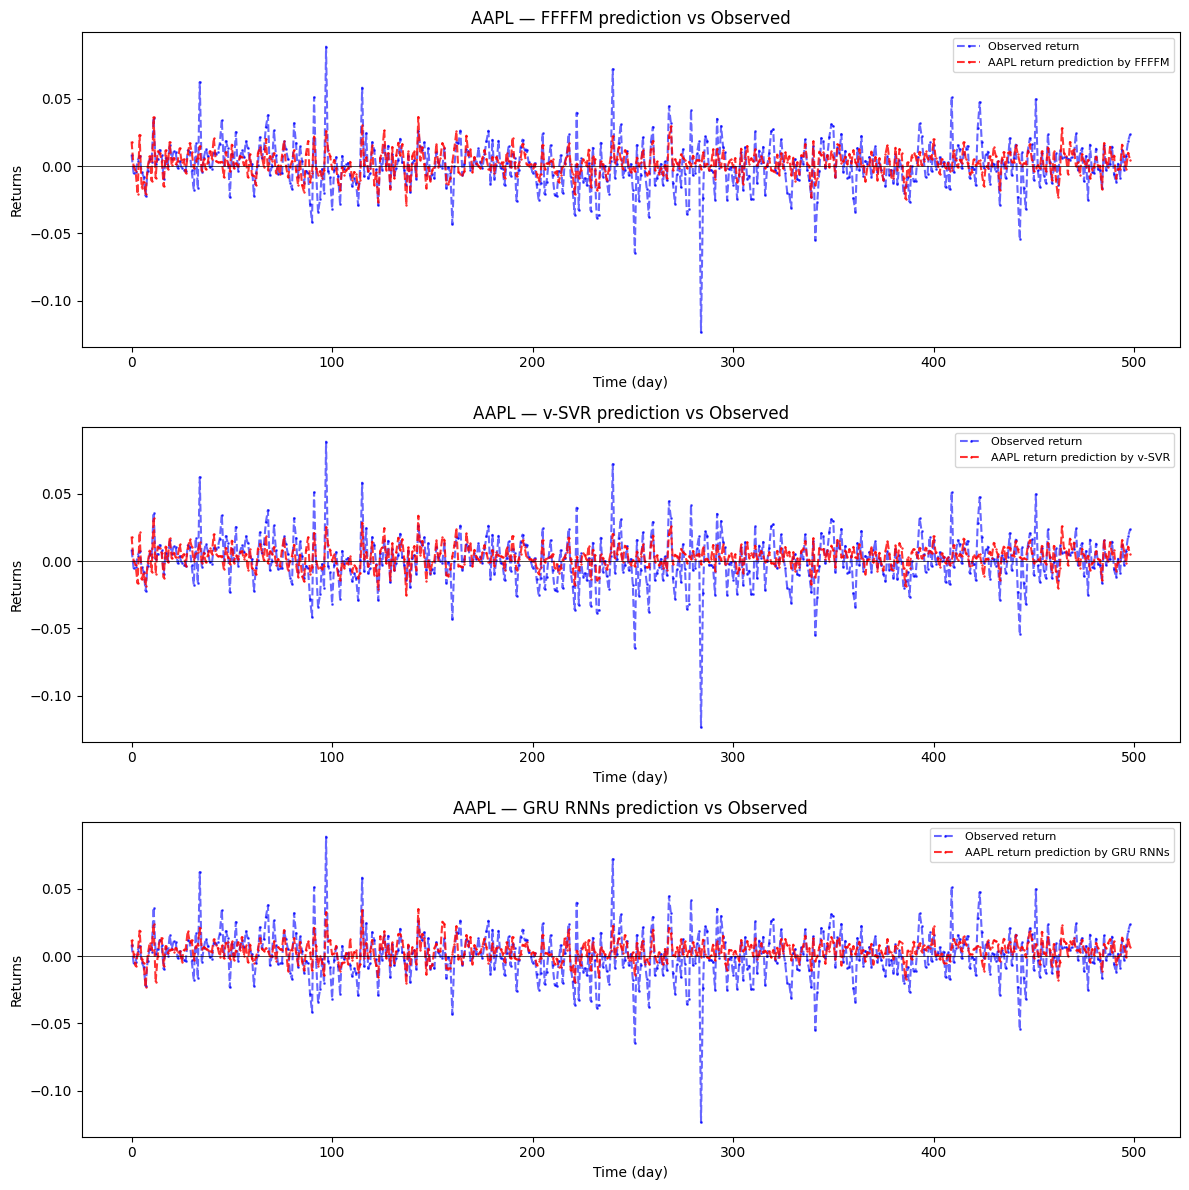

Saved: /content/drive/MyDrive/portfolio_project/fig6_aapl_predictions.png


In [ ]:
# ── LOAD FFFFM AND SVR PREDICTIONS ─────────────────────────
ffffm_preds_df = pd.read_csv(os.path.join(BASE_DIR, 'ffffm_predictions.csv'),
                              index_col='Date', parse_dates=True)
svr_preds_df   = pd.read_csv(os.path.join(BASE_DIR, 'svr_predictions.csv'),
                              index_col='Date', parse_dates=True)

# Actual AAPL validation returns
y_valid_aapl = valid['AAPL_excess'].values
time_axis    = range(len(y_valid_aapl))

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

models_to_plot = [
    ('FFFFM',   ffffm_preds_df['AAPL'].values, axes[0]),
    ('v-SVR',   svr_preds_df['AAPL'].values,   axes[1]),
    ('GRU RNNs', gru_preds['AAPL'],            axes[2]),
]

for name, preds, ax in models_to_plot:
    ax.plot(time_axis, y_valid_aapl,
            linestyle='--', marker='.',
            markersize=2, label='Observed return',
            color='blue', alpha=0.6)
    ax.plot(time_axis, preds,
            linestyle='--', marker='+',
            markersize=2, label=f'AAPL return prediction by {name}',
            color='red', alpha=0.8)
    ax.set_xlabel('Time (day)')
    ax.set_ylabel('Returns')
    ax.set_title(f'AAPL — {name} prediction vs Observed')
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
fig6_path = os.path.join(BASE_DIR, 'fig6_aapl_predictions.png')
plt.savefig(fig6_path, dpi=150)
plt.show()
print(f"Saved: {fig6_path}")

In [ ]:
# Save GRU predictions
gru_preds_df = pd.DataFrame(gru_preds, index=valid.index)
gru_preds_df.to_csv(os.path.join(BASE_DIR, 'gru_predictions.csv'))
print("Saved GRU predictions!")
print(gru_preds_df.head())

# Save models
for stock, model in gru_models.items():
    model_path = os.path.join(BASE_DIR, f'gru_model_{stock}.keras')
    model.save(model_path)
    print(f"Saved model: {model_path}")

Saved GRU predictions!
                MSFT      AAPL      SONY
Date                                    
2011-12-05  0.009924  0.012117  0.011875
2011-12-06 -0.000383  0.001562 -0.003341
2011-12-07 -0.001097 -0.007298 -0.001504
2011-12-08 -0.010741  0.001273 -0.036409
2011-12-09  0.010201  0.018909  0.023577
Saved model: /content/drive/MyDrive/portfolio_project/gru_model_MSFT.keras
Saved model: /content/drive/MyDrive/portfolio_project/gru_model_AAPL.keras
Saved model: /content/drive/MyDrive/portfolio_project/gru_model_SONY.keras
